# DEMETER -- Exploratory Data Analysis

French electricity demand (load_mw) for the continental grid: national plus 12 metropolitan regions (Corsica excluded by design). This notebook closes the W1 milestone (data acquisition + EDA).

**Conventions**

- All timestamps are stored in UTC. Any time-of-day display axis is converted to Europe/Paris; all aggregation arithmetic stays in UTC to avoid DST artifacts.
- Units: load in MW, temperature in degC, wind in m/s, radiation in W/m2, precipitation in mm, cloud cover in percent.
- Figures are built with plotly (plotly.express / plotly.graph_objects) and rendered as static PNG via the kaleido engine, so the executed notebook embeds image/png outputs that display reliably on GitHub, HF and nbviewer without plotly's interactive JavaScript.
- The hierarchical invariant `sum(regional load) ~= national load +-2%` has already PASSED its gate (see the dedicated invariant-error figure below).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Emit static PNG (kaleido) as the default renderer so every fig.show() call
# embeds an image/png output in the executed notebook -- no interactive JS.
pio.renderers.default = "png"

# Shared static-image defaults: a clean template and a legible default size.
PNG_SCALE = 2  # retina-quality raster
pio.templates.default = "plotly_white"

# Resolve the project root from the notebook location so paths work top-to-bottom.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src" / "config.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import config  # noqa: E402

PROCESSED = PROJECT_ROOT / config.PROCESSED_DIR
PARIS_TZ = config.PARIS_TZ

print("project root:", PROJECT_ROOT)
print("processed dir:", PROCESSED)

project root: /Users/arnaudpaquet/Documents/electricity_consumption_forecast
processed dir: /Users/arnaudpaquet/Documents/electricity_consumption_forecast/data/processed


## Load the processed tables

In [2]:
national = pd.read_parquet(PROCESSED / "consumption_national_hourly.parquet")
regional = pd.read_parquet(PROCESSED / "consumption_regional_hourly.parquet")
weather = pd.read_parquet(PROCESSED / "weather_city_hourly.parquet")
mapping = pd.read_parquet(PROCESSED / "region_city_mapping.parquet")
calendar = pd.read_parquet(PROCESSED / "calendar_daily.parquet")
forecast = pd.read_parquet(PROCESSED / "forecast_rte_dayahead_baseline.parquet")

for name, df in [
    ("national", national),
    ("regional", regional),
    ("weather", weather),
    ("forecast", forecast),
]:
    print(f"{name:9s} {len(df):>9,d} rows  {df.ts_utc.min()} -> {df.ts_utc.max()}")
print(
    f"{'regions':9s} {regional.region_code.nunique()} regions, {weather.city_code.nunique()} cities"
)
print(f"{'calendar':9s} {len(calendar):>9,d} rows  {calendar.date.min()} -> {calendar.date.max()}")

national    116,817 rows  2013-01-01 00:00:00+00:00 -> 2026-04-30 21:00:00+00:00
regional  1,376,184 rows  2013-01-01 00:00:00+00:00 -> 2026-01-31 22:00:00+00:00
weather   1,416,384 rows  2013-01-01 00:00:00+00:00 -> 2026-06-19 23:00:00+00:00
forecast     30,078 rows  2023-01-01 23:00:00+00:00 -> 2026-06-19 21:00:00+00:00
regions   12 regions, 12 cities
calendar      6,574 rows  2013-01-01 -> 2030-12-31


## Derived frames

A national-level mean temperature (simple mean of the 12 city centroids; the v1 region->city weights are all 1.0, so an unweighted mean is the consistent national proxy), and a tidy national frame carrying Europe/Paris calendar fields for the seasonality and holiday figures.

In [3]:
# National mean weather across the 12 centroid cities (UTC index preserved).
nat_weather = weather.groupby("ts_utc", as_index=False).agg(temp_c=("temperature_2m", "mean"))

# Sum of regional load per hour for the invariant figure.
reg_sum = (
    regional.groupby("ts_utc", as_index=False)["load_mw"]
    .sum()
    .rename(columns={"load_mw": "sum_regional_mw"})
)

# Tidy national frame with Paris-local calendar attributes for display.
nat = national[["ts_utc", "load_mw", "is_estimated"]].copy()
nat["ts_paris"] = nat["ts_utc"].dt.tz_convert(PARIS_TZ)
nat["date"] = nat["ts_paris"].dt.date
nat["hour_paris"] = nat["ts_paris"].dt.hour
nat["dow_paris"] = nat["ts_paris"].dt.dayofweek  # 0=Mon
nat["year"] = nat["ts_paris"].dt.year
nat["month"] = nat["ts_paris"].dt.month

# Attach daily calendar flags (join on Paris-local calendar date).
cal = calendar.copy()
cal["date"] = pd.to_datetime(cal["date"]).dt.date
nat = nat.merge(cal[["date", "is_workday", "is_bank_holiday"]], on="date", how="left")
print("national rows with calendar match:", nat["is_workday"].notna().mean())
nat.head(3)

national rows with calendar match: 1.0


,ts_utc,load_mw,is_estimated,ts_paris,date,hour_paris,dow_paris,year,month,is_workday,is_bank_holiday
0,2013-01-01 00:00:00+00:00,57816.0,False,2013-01-01 01:00:00+01:00,2013-01-01,1,1,2013,1,False,True
1,2013-01-01 01:00:00+00:00,56951.5,False,2013-01-01 02:00:00+01:00,2013-01-01,2,1,2013,1,False,True
2,2013-01-01 02:00:00+00:00,53508.0,False,2013-01-01 03:00:00+01:00,2013-01-01,3,1,2013,1,False,True


## Figure 1 -- Load vs temperature U-curve (national)

U-curve overlap: 2013-01-01 00:00:00+00:00 -> 2026-04-30 21:00:00+00:00 (116,817 hrs)


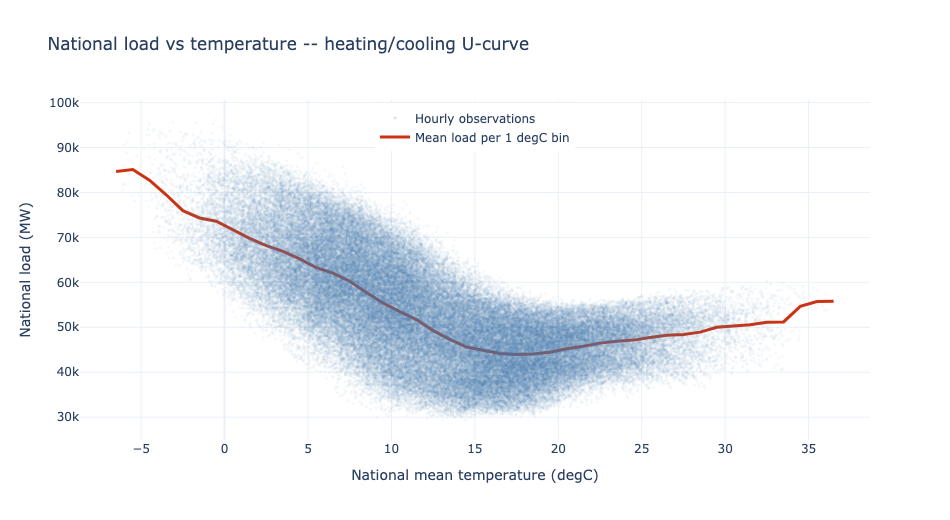

In [4]:
df = national[["ts_utc", "load_mw"]].merge(nat_weather, on="ts_utc", how="inner")
print("U-curve overlap:", df.ts_utc.min(), "->", df.ts_utc.max(), f"({len(df):,} hrs)")

# Binned mean load by 1 degC temperature bin to draw the conditional mean curve.
bins = np.arange(np.floor(df.temp_c.min()), np.ceil(df.temp_c.max()) + 1, 1.0)
df["tbin"] = pd.cut(df.temp_c, bins)
binned = df.groupby("tbin", observed=True)["load_mw"].mean()
centers = [iv.mid for iv in binned.index]

fig = go.Figure()
fig.add_trace(
    go.Scattergl(
        x=df.temp_c,
        y=df.load_mw,
        mode="markers",
        marker=dict(size=3, color="#4477aa", opacity=0.05),
        name="Hourly observations",
        hoverinfo="skip",
    )
)
fig.add_trace(
    go.Scatter(
        x=centers,
        y=binned.values,
        mode="lines",
        line=dict(color="#cc3311", width=3),
        name="Mean load per 1 degC bin",
    )
)
fig.update_layout(
    title="National load vs temperature -- heating/cooling U-curve",
    xaxis_title="National mean temperature (degC)",
    yaxis_title="National load (MW)",
    width=950,
    height=520,
    legend=dict(x=0.5, y=0.99, xanchor="center", yanchor="top"),
)
fig.show()

Hourly national load against national mean temperature. The U shape is the central physical fact of French demand: a strong heating slope below roughly 15 degC (electric heating is widespread in France) and a milder cooling slope above roughly 20 degC.

## Figure 2 -- Weekly seasonality heatmap (hour-of-day x day-of-week)

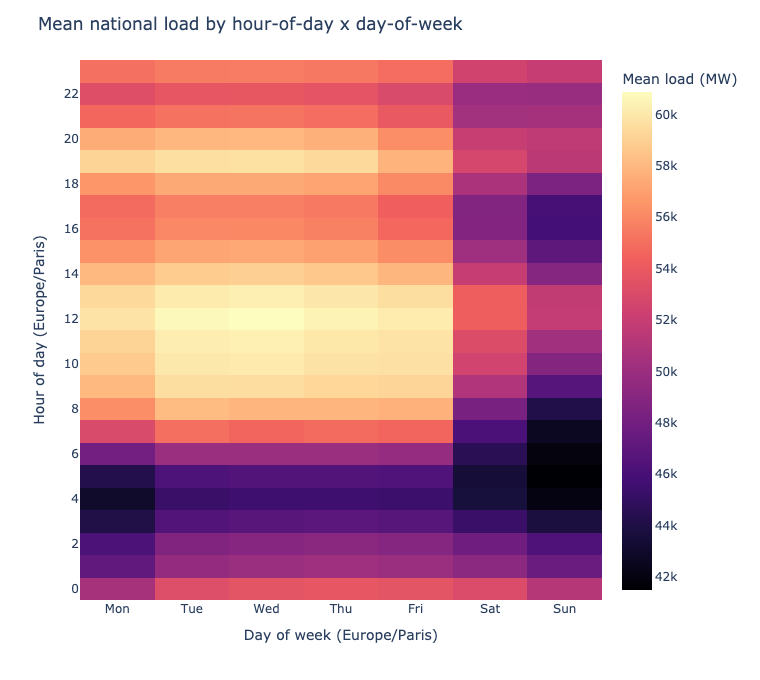

In [5]:
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
pivot = nat.pivot_table(
    index="hour_paris", columns="dow_paris", values="load_mw", aggfunc="mean"
).reindex(index=range(24), columns=range(7))

fig = px.imshow(
    pivot.values,
    x=dow_names,
    y=list(range(24)),
    origin="lower",
    aspect="auto",
    color_continuous_scale="Magma",
    labels=dict(color="Mean load (MW)"),
)
fig.update_layout(
    title="Mean national load by hour-of-day x day-of-week",
    xaxis_title="Day of week (Europe/Paris)",
    yaxis_title="Hour of day (Europe/Paris)",
    width=760,
    height=680,
)
fig.update_yaxes(tickmode="array", tickvals=list(range(0, 24, 2)))
fig.show()

Mean national load by Europe/Paris hour-of-day and day-of-week. Reveals the morning and evening peaks, the weekday-vs-weekend gap, and the Paris-local daily rhythm (aggregation is computed in UTC then labelled in Paris time).

## Figure 3 -- Regional load composition (stacked area)

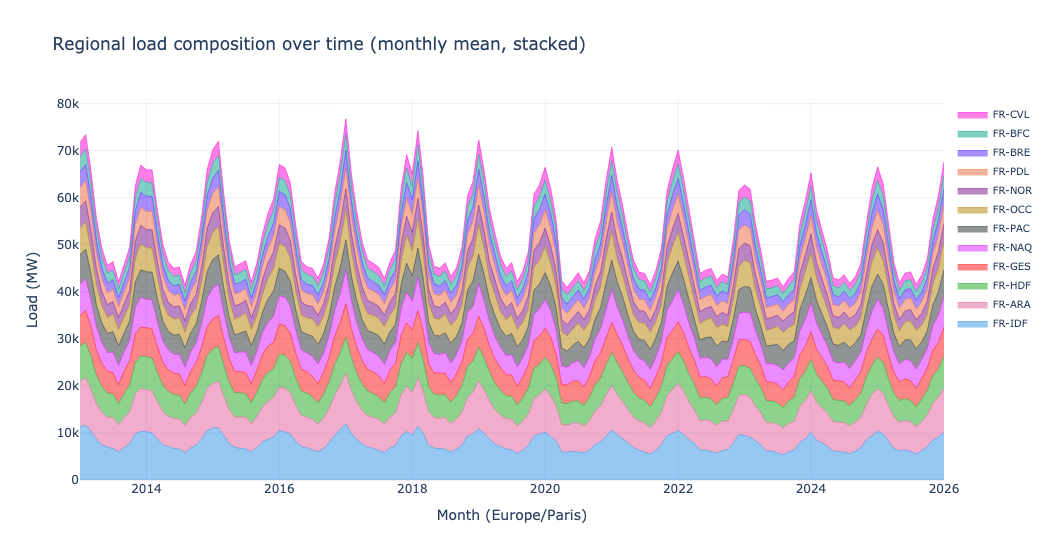

Average national share by region (percent):
region_code
FR-IDF    14.90
FR-ARA    13.99
FR-HDF    10.65
FR-GES     9.60
FR-NAQ     9.23
FR-PAC     8.70
FR-OCC     8.02
FR-NOR     5.91
FR-PDL     5.75
FR-BRE     4.77
FR-BFC     4.50
FR-CVL     3.98


In [6]:
reg = regional.copy()
# Bucket to month using the Paris-local wall-clock date (tz dropped only for
# the month label, which is the intended grouping key).
reg["month"] = (
    reg["ts_utc"].dt.tz_convert(PARIS_TZ).dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()
)
monthly = reg.groupby(["month", "region_code"])["load_mw"].mean().unstack("region_code")
# Order regions by overall mean load so the largest sit at the bottom of the stack.
order = monthly.mean().sort_values(ascending=False).index.tolist()
monthly = monthly[order]

palette = px.colors.qualitative.Dark24
fig = go.Figure()
for i, rc in enumerate(order):
    fig.add_trace(
        go.Scatter(
            x=monthly.index,
            y=monthly[rc].values,
            mode="lines",
            name=rc,
            line=dict(width=0.5, color=palette[i % len(palette)]),
            stackgroup="one",
        )
    )
fig.update_layout(
    title="Regional load composition over time (monthly mean, stacked)",
    xaxis_title="Month (Europe/Paris)",
    yaxis_title="Load (MW)",
    width=1050,
    height=560,
    legend=dict(orientation="v", x=1.01, y=1.0, font=dict(size=10)),
)
fig.update_xaxes(range=[monthly.index.min(), monthly.index.max()])
fig.show()

share = (monthly.mean() / monthly.mean().sum() * 100).round(2)
print("Average national share by region (percent):")
print(share.to_string())

Monthly-mean regional load stacked over time. Ile-de-France (Paris) and Auvergne-Rhone-Alpes (Lyon) dominate; the band heights show the seasonal swing is shared across regions while the relative composition stays stable.

## Figure 4 -- Holiday effect (bank holidays vs normal workdays)

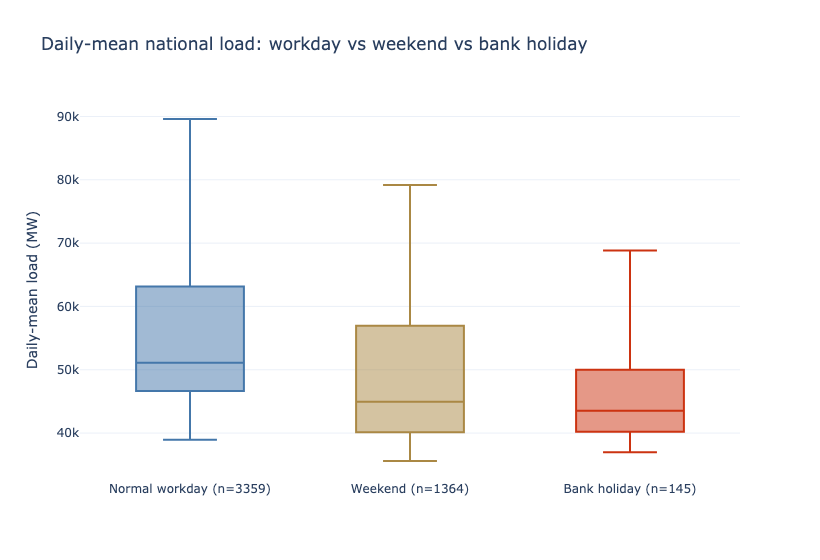

Median workday load : 51,113 MW
Median holiday load : 43,527 MW
Bank-holiday median load drop vs workday: 14.8 percent


In [7]:
daily = (
    nat.groupby("date")
    .agg(
        load_mw=("load_mw", "mean"),
        is_workday=("is_workday", "first"),
        is_bank_holiday=("is_bank_holiday", "first"),
        dow=("dow_paris", "first"),
    )
    .reset_index()
)

normal_workday = daily[(daily.is_workday) & (~daily.is_bank_holiday)]["load_mw"]
bank_holiday = daily[daily.is_bank_holiday]["load_mw"]
weekend = daily[(daily.dow >= 5) & (~daily.is_bank_holiday)]["load_mw"]

groups = [
    ("Normal workday", normal_workday, "#4477aa"),
    ("Weekend", weekend, "#aa8844"),
    ("Bank holiday", bank_holiday, "#cc3311"),
]

fig = go.Figure()
for label, series, color in groups:
    fig.add_trace(
        go.Box(
            y=series.values,
            name=f"{label} (n={len(series)})",
            marker_color=color,
            boxpoints=False,
        )
    )
fig.update_layout(
    title="Daily-mean national load: workday vs weekend vs bank holiday",
    yaxis_title="Daily-mean load (MW)",
    width=820,
    height=560,
    showlegend=False,
)
fig.show()

drop = (1 - bank_holiday.median() / normal_workday.median()) * 100
print(f"Median workday load : {normal_workday.median():,.0f} MW")
print(f"Median holiday load : {bank_holiday.median():,.0f} MW")
print(f"Bank-holiday median load drop vs workday: {drop:.1f} percent")

Distribution of daily-mean national load on bank holidays versus ordinary workdays (weekends excluded so the comparison isolates the holiday effect, not the weekend effect). Bank holidays sit clearly below workdays and demand behaves like a Sunday.

## Figure 5 -- Seasonal and long-run trend

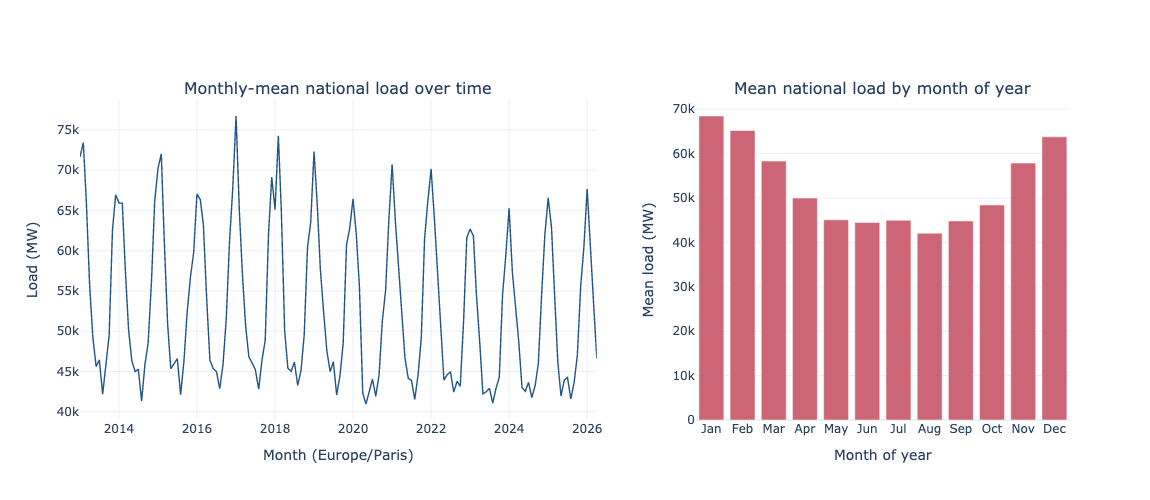

In [8]:
ts = nat.set_index("ts_paris").sort_index()
monthly_ts = ts["load_mw"].resample("MS").mean()
month_profile = nat.groupby("month")["load_mw"].mean()
mlabels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Monthly-mean national load over time", "Mean national load by month of year"),
    column_widths=[0.58, 0.42],
)
fig.add_trace(
    go.Scatter(
        x=monthly_ts.index,
        y=monthly_ts.values,
        mode="lines",
        line=dict(color="#225588", width=1.4),
        name="Monthly mean",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Bar(x=mlabels, y=month_profile.values, marker_color="#cc6677", name="Month profile"),
    row=1,
    col=2,
)
fig.update_xaxes(title_text="Month (Europe/Paris)", row=1, col=1)
fig.update_yaxes(title_text="Load (MW)", row=1, col=1)
fig.update_xaxes(title_text="Month of year", row=1, col=2)
fig.update_yaxes(title_text="Mean load (MW)", row=1, col=2)
fig.update_layout(width=1150, height=500, showlegend=False)
fig.show()

Left: monthly-mean national load across all years, exposing the strong winter peak and summer trough of a heating-dominated system. Right: month-of-year profile averaged over years, the clean annual cycle.

## Figure 6 -- Hierarchical invariant error

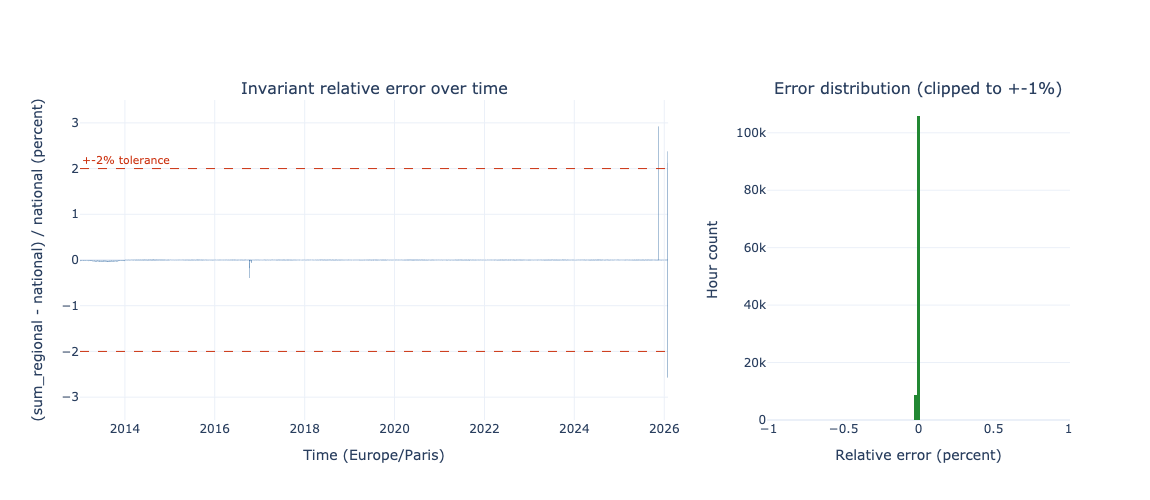

Hours within +-2%       : 99.993 percent  (n=114,682)
Max abs error, FINAL    : 0.393 percent
Mean abs error (all)    : 0.0029 percent
p95 abs error (all)     : 0.0164 percent
VERDICT: PASS


In [9]:
inv = national[["ts_utc", "load_mw", "is_estimated"]].merge(reg_sum, on="ts_utc", how="inner")
inv["rel_err"] = (inv.sum_regional_mw - inv.load_mw) / inv.load_mw
inv["ts_paris"] = inv["ts_utc"].dt.tz_convert(PARIS_TZ)

within = (inv.rel_err.abs() <= 0.02).mean() * 100
final_max = inv.loc[~inv.is_estimated, "rel_err"].abs().max() * 100

fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.66, 0.34],
    subplot_titles=("Invariant relative error over time", "Error distribution (clipped to +-1%)"),
)
fig.add_trace(
    go.Scattergl(
        x=inv.ts_paris,
        y=inv.rel_err * 100,
        mode="lines",
        line=dict(color="#4477aa", width=0.5),
        opacity=0.7,
        name="Relative error",
        hoverinfo="skip",
    ),
    row=1,
    col=1,
)
for yval in (2, -2):
    fig.add_hline(y=yval, line=dict(color="#cc3311", dash="dash", width=1), row=1, col=1)
fig.add_annotation(
    x=inv.ts_paris.iloc[0],
    y=2,
    text="+-2% tolerance",
    showarrow=False,
    font=dict(color="#cc3311", size=11),
    xanchor="left",
    yanchor="bottom",
    row=1,
    col=1,
)
fig.add_trace(
    go.Histogram(
        x=np.clip(inv.rel_err * 100, -1, 1), nbinsx=120, marker_color="#228833", name="Hour count"
    ),
    row=1,
    col=2,
)
fig.update_yaxes(
    title_text="(sum_regional - national) / national (percent)", range=[-3.5, 3.5], row=1, col=1
)
fig.update_xaxes(title_text="Time (Europe/Paris)", row=1, col=1)
fig.update_xaxes(title_text="Relative error (percent)", row=1, col=2)
fig.update_yaxes(title_text="Hour count", row=1, col=2)
fig.update_layout(width=1150, height=500, showlegend=False)
fig.show()

print(f"Hours within +-2%       : {within:.3f} percent  (n={len(inv):,})")
print(f"Max abs error, FINAL    : {final_max:.3f} percent")
print(f"Mean abs error (all)    : {inv.rel_err.abs().mean()*100:.4f} percent")
print(f"p95 abs error (all)     : {inv.rel_err.abs().quantile(0.95)*100:.4f} percent")
print("VERDICT: PASS" if within >= 99.0 else "VERDICT: REVIEW")

Per-hour relative error `(sum_regional - national) / national` over the full overlap. The +-2% tolerance band is drawn. 

Result: essentially all hours fall inside +-2%; among FINAL (consolidated) hours the maximum absolute error is well below the tolerance. Any rare breach is a provisory `is_estimated=True` hour that self-corrects on consolidation. **Verdict: PASS.**

## Figure 7 -- RTE day-ahead baseline error (the number to beat)

RTE's own published day-ahead forecast versus actual national load on the overlapping window (2023+, restricted to where actual load exists). The error-by-hour-of-day profile and the headline MAPE establish the baseline the model ladder must beat in W3-W4. This uses the published forecast directly (no leakage); it is shown here only as a reference target.

forecast overlap: 2023-01-01 23:00:00+00:00 -> 2026-04-30 21:00:00+00:00 (28,875 hrs)
RTE day-ahead MAPE over overlap: 2.77 percent


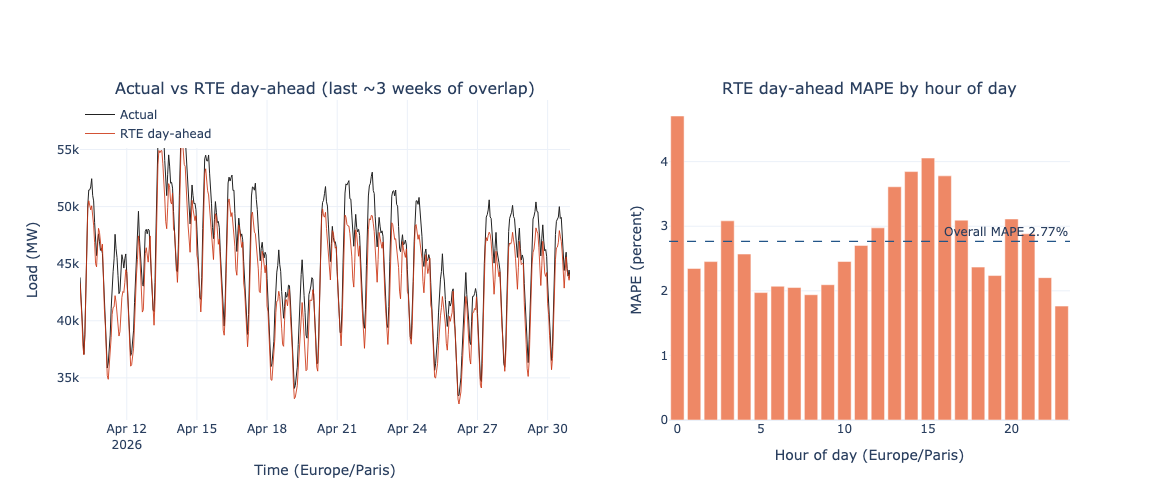

In [10]:
fc = forecast.merge(national[["ts_utc", "load_mw"]], on="ts_utc", how="inner")
fc = fc.dropna(subset=["forecast_mw", "load_mw"])
fc["ape"] = (fc.forecast_mw - fc.load_mw).abs() / fc.load_mw
fc["hour_paris"] = fc["ts_utc"].dt.tz_convert(PARIS_TZ).dt.hour
mape = fc.ape.mean() * 100
print("forecast overlap:", fc.ts_utc.min(), "->", fc.ts_utc.max(), f"({len(fc):,} hrs)")
print(f"RTE day-ahead MAPE over overlap: {mape:.2f} percent")

by_hour = fc.groupby("hour_paris")["ape"].mean() * 100
sample = fc.sort_values("ts_utc").iloc[-24 * 21 :]  # last ~3 weeks
sample_paris = sample.ts_utc.dt.tz_convert(PARIS_TZ)

fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.55, 0.45],
    subplot_titles=(
        "Actual vs RTE day-ahead (last ~3 weeks of overlap)",
        "RTE day-ahead MAPE by hour of day",
    ),
)
fig.add_trace(
    go.Scatter(
        x=sample_paris,
        y=sample.load_mw,
        mode="lines",
        line=dict(color="#222222", width=1.0),
        name="Actual",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=sample_paris,
        y=sample.forecast_mw,
        mode="lines",
        line=dict(color="#cc3311", width=1.0),
        opacity=0.85,
        name="RTE day-ahead",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Bar(
        x=by_hour.index,
        y=by_hour.values,
        marker_color="#ee8866",
        name="MAPE by hour",
        showlegend=False,
    ),
    row=1,
    col=2,
)
fig.add_hline(
    y=mape,
    line=dict(color="#225588", dash="dash", width=1.2),
    annotation_text=f"Overall MAPE {mape:.2f}%",
    annotation_position="top right",
    row=1,
    col=2,
)
fig.update_xaxes(title_text="Time (Europe/Paris)", row=1, col=1)
fig.update_yaxes(title_text="Load (MW)", row=1, col=1)
fig.update_xaxes(title_text="Hour of day (Europe/Paris)", row=1, col=2)
fig.update_yaxes(title_text="MAPE (percent)", row=1, col=2)
fig.update_layout(width=1150, height=500, legend=dict(x=0.0, y=1.0, xanchor="left", yanchor="top"))
fig.show()

## Figure 8 -- Load distribution by region

Hourly load distribution per region (boxplot, ordered by median). Quantifies both the scale spread (Ile-de-France an order of magnitude above the smallest regions) and the within-region variability the regional models will face.

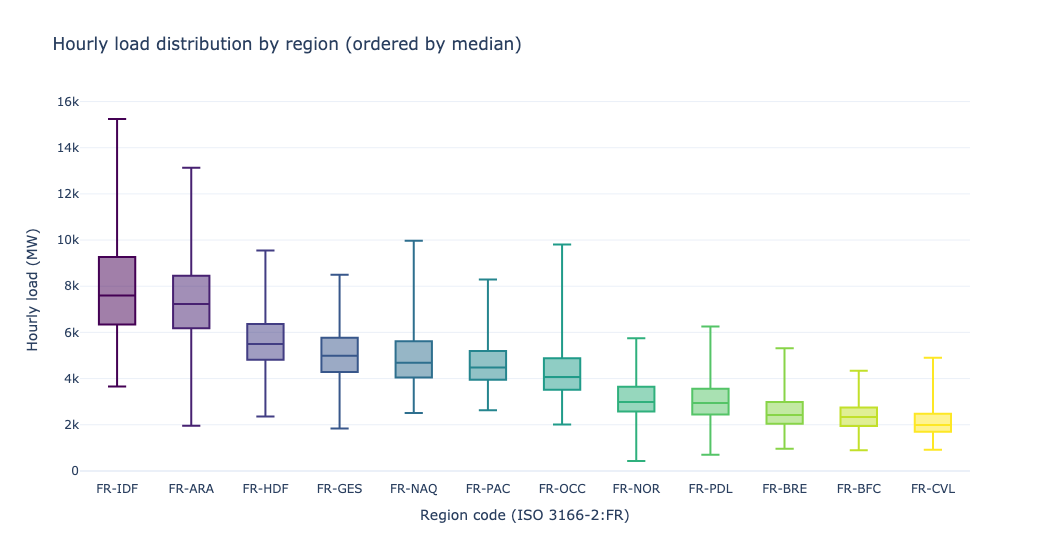

In [11]:
order = (
    regional.groupby("region_code")["load_mw"].median().sort_values(ascending=False).index.tolist()
)

# Plotly assigns sequential colours by trace order; one box trace per region.
colors = px.colors.sample_colorscale("Viridis", [i / (len(order) - 1) for i in range(len(order))])
fig = go.Figure()
for i, rc in enumerate(order):
    fig.add_trace(
        go.Box(
            y=regional.loc[regional.region_code == rc, "load_mw"].values,
            name=rc,
            marker_color=colors[i],
            boxpoints=False,
        )
    )
fig.update_layout(
    title="Hourly load distribution by region (ordered by median)",
    xaxis_title="Region code (ISO 3166-2:FR)",
    yaxis_title="Hourly load (MW)",
    width=1050,
    height=560,
    showlegend=False,
)
fig.show()